## Timing Your Code, Reliably



### Benchmarks

The following code tests three difference computational tasks:
  1. A CPU-Heavy, Python-only Math Task (sum and multiply numbers in a python loop).
  2. An IO-Heavy, OS-only Task (wait until the OS says a microsecond has passed) .
  3. A CPU-Heavy, Out-of-Python Task (randomize, sum, and multiply numbers with Numpy).


We'll look at how one might want to speed up each of these, and how it impacts performance:
  1. Using Python multi-threading,
  2. Using Python multi-processing,
  3. Using multi-threading with OMP, MKL, and OPENBLAS


Finally, we'll look at difference "clocks", to understand better what they are trying to tell us, and which are more useful for interpreting performance changes:
  1. Wall Time (`time.perf_counter()`) [^1]
  2. OS Process Time (`time.process_time()`)



In [ ]:
from itertools import product
import json
import subprocess, sys, os
import random

from tqdm import tqdm


### Parameters 
n_repeats = 5

tasks = [
    {'task': 'cpu', 'execution': 'serial'},
    {'task': 'cpu', 'execution': 'threads'},
    {'task': 'cpu', 'execution': 'multiprocessing'},
    {'task': 'io', 'execution': 'serial'},
    {'task': 'io', 'execution': 'threads'},
    {'task': 'io', 'execution': 'multiprocessing'},
    {'task': 'numpy', 'execution': 'serial'},
    {'task': 'numpy', 'execution': 'threads'},
    {'task': 'numpy', 'execution': 'multiprocessing'},
]

envs = [
    {"OMP_NUM_THREADS": "1", "MKL_NUM_THREADS": "1", "OPENBLAS_NUM_THREADS": "1"},
    {"OMP_NUM_THREADS": "8", "MKL_NUM_THREADS": "8", "OPENBLAS_NUM_THREADS": "8"},
]


### Run the Benchmarks

runs = list(product(tasks * n_repeats, envs))
random.shuffle(runs)

results = []
for job, env in tqdm(runs):
    out = subprocess.run([sys.executable, "benchmark_demo1.py", job['task'], job['execution']], env=os.environ | env, check=False, text=True, capture_output=True)
    if out.returncode != 0:
        print(out.stderr)
        raise RuntimeError()
    
    results.append(json.loads(out.stdout))


# Cache to File
with open('perf_cache.json', 'w') as f:
    json.dump(results, f)
    

100%|██████████| 90/90 [02:51<00:00,  1.91s/it]


In [224]:
import pandas as pd

df = pd.read_json('perf_cache.json').astype({"OMP_NUM_THREADS": int, "MKL_NUM_THREADS": int, "OPENBLAS_NUM_THREADS": int})
df['OPENBLAS_multithreaded'] = df['OPENBLAS_NUM_THREADS'].map({1: "single", 2: pd.NA, 4: "multi", 8: "multi"})
df['task_detailed'] = df['task']
df.loc[(df['task'] == 'numpy') & (df['OPENBLAS_multithreaded'] == 'multi'), 'task_detailed'] = 'numpy_multi-threaded'
df.loc[(df['task'] == 'numpy') & (df['OPENBLAS_multithreaded'] == 'single'), 'task_detailed'] = 'numpy_single-threaded'
df.dropna(inplace=True)
# df = df.copy()
df.head(10)

,task,execution,wall,process,OMP_NUM_THREADS,MKL_NUM_THREADS,OPENBLAS_NUM_THREADS,id,OPENBLAS_multithreaded,task_detailed
0,numpy,multiprocessing,2.924,10.266,4,4,4,519b8e17,multi,numpy_multi-threaded
1,cpu,threads,4.819,4.812,4,4,4,f6417e19,multi,cpu
3,cpu,serial,4.690,4.672,1,1,1,4a3dbf6a,single,cpu
4,cpu,serial,5.829,5.766,1,1,1,4efdea3f,single,cpu
5,io,threads,0.135,0.031,4,4,4,892a55dc,multi,io
7,io,threads,0.141,0.047,1,1,1,9324b510,single,io
8,io,threads,0.128,0.062,1,1,1,81d64267,single,io
9,cpu,multiprocessing,4.275,16.109,8,8,8,12f353a7,multi,cpu
10,numpy,multiprocessing,2.415,13.625,8,8,8,95479f93,multi,numpy_multi-threaded
12,numpy,serial,1.324,3.438,4,4,4,09e4c77d,multi,numpy_multi-threaded


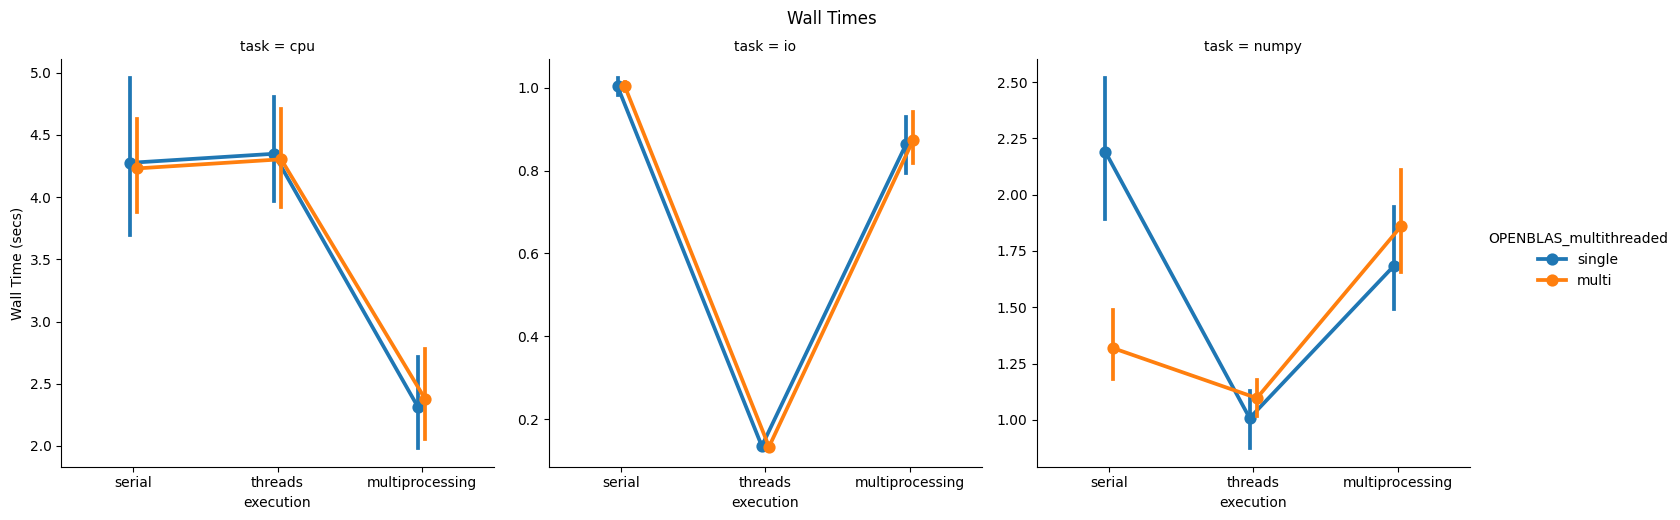

In [242]:
import matplotlib.pyplot as plt
import seaborn as sns

def melt(df: pd.DataFrame, cols: list[str], var_name: str, value_name: str) -> pd.DataFrame:
    return df.melt(id_vars=list(df.columns.drop(cols)), value_vars=cols, var_name=var_name, value_name=value_name)

tidy = melt(df, ['wall', 'process'], 'clock', 'time')

sns.catplot(
    data=tidy[(tidy['clock'] == 'wall')].dropna(), 
    kind='point', 
    x='execution', y='time', dodge=True, order=['serial', 'threads', 'multiprocessing'],
    hue='OPENBLAS_multithreaded', hue_order=['single', 'multi'],
    col='task', col_order=['cpu', 'io', 'numpy'], sharey=False, 
);
plt.suptitle('Wall Times', y=1.03)
plt.gcf().axes[0].set_ylabel('Wall Time (secs)');

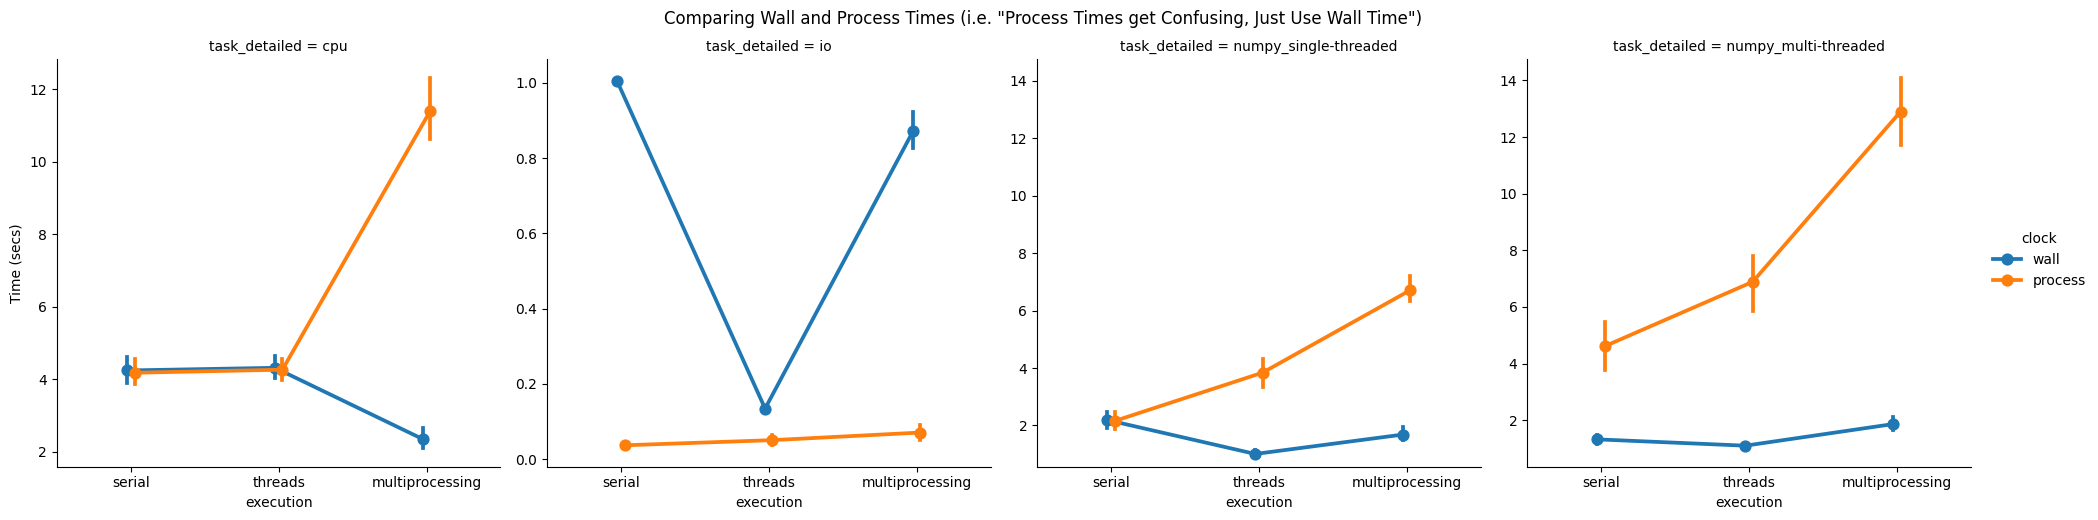

In [244]:
sns.catplot(
    data=tidy, 
    kind='point', 
    x='execution', y='time', dodge=True, order=['serial', 'threads', 'multiprocessing'],
    hue='clock',# hue_order=['single', 'multi'],
    col='task_detailed', col_order=['cpu', 'io', 'numpy_single-threaded', 'numpy_multi-threaded'], sharey=False, 
);
plt.suptitle('Comparing Wall and Process Times (i.e. "Process Times get Confusing, Just Use Wall Time")', y=1.03)
plt.gcf().axes[0].set_ylabel('Time (secs)');
numpy_max_time = max(plt.gcf().axes[2].get_ylim()[1], plt.gcf().axes[3].get_ylim()[1])
plt.gcf().axes[2].set_ylim(None, numpy_max_time)
plt.gcf().axes[3].set_ylim(None, numpy_max_time);